In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [25]:
df = pd.read_csv('StudentsPerformance.csv')

In [26]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [21]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


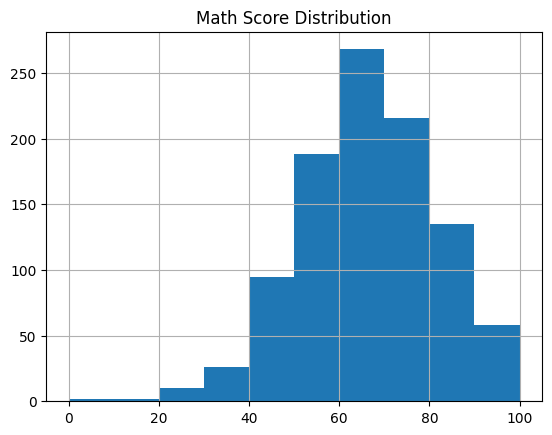

In [28]:
plt.figure()
df['math score'].hist()
plt.title("Math Score Distribution")
plt.show()

Text(0.5, 1.0, 'Reading Score Distribution')

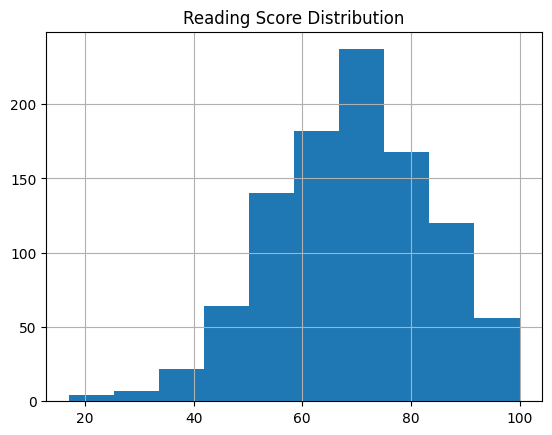

In [30]:
df['reading score'].hist()
plt.title("Reading Score Distribution")

Text(0.5, 1.0, 'Writing Score Distribution')

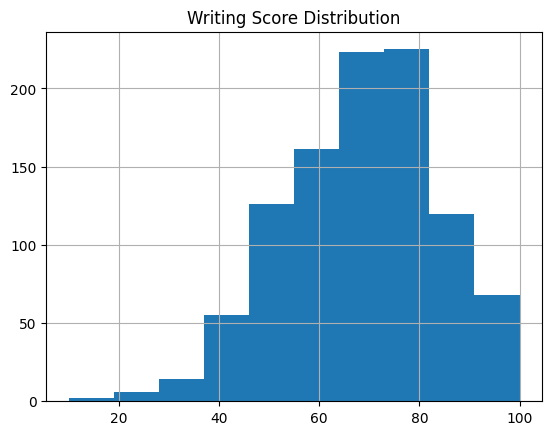

In [31]:
df['writing score'].hist()
plt.title("Writing Score Distribution")

In [35]:
corr = df[['math score', 'reading score', 'writing score']].corr()

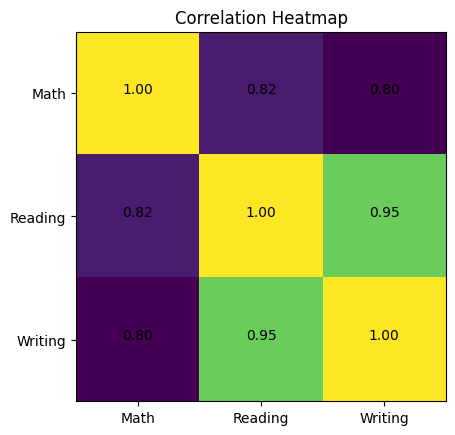

In [36]:
plt.figure()
plt.imshow(corr)

plt.title("Correlation Heatmap")
plt.xticks([0,1,2], ['Math','Reading','Writing'])
plt.yticks([0,1,2], ['Math','Reading','Writing'])

for i in range(3):
    for j in range(3):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center')

plt.show()

In [40]:
df['math score'].value_counts()

math score
65    36
62    35
69    32
59    32
73    27
      ..
24     1
26     1
19     1
23     1
8      1
Name: count, Length: 81, dtype: int64

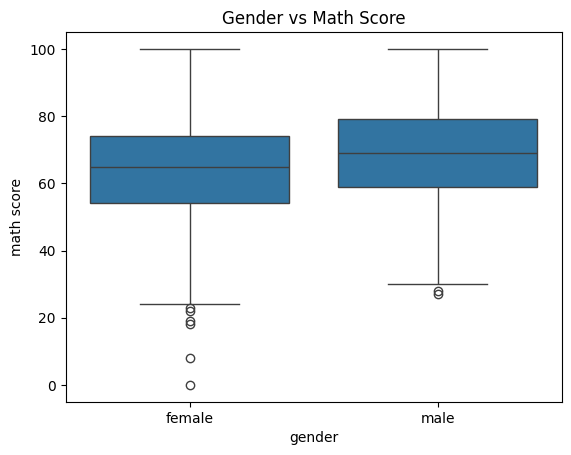

In [47]:
sns.boxplot(x='gender', y='math score', data=df)
plt.title("Gender vs Math Score")
plt.show()

In [43]:
df.groupby('math score')[['reading score','writing score']].mean()

,reading score,writing score
math score,,
0,17.000000,10.000000
8,24.000000,23.000000
18,32.000000,28.000000
19,38.000000,32.000000
22,39.000000,33.000000
...,...,...
96,95.333333,97.000000
97,91.833333,90.500000
98,91.000000,93.000000


<Axes: title={'center': 'reading score'}, xlabel='math score'>

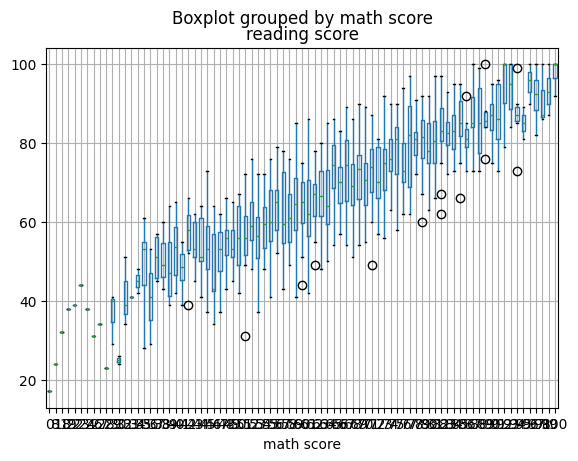

In [45]:
df.boxplot(column='reading score', by='math score')

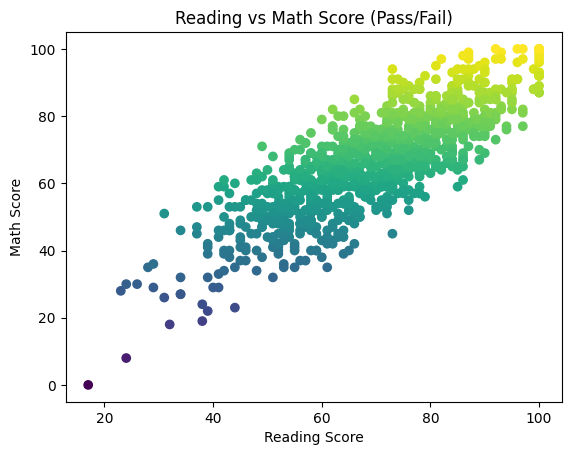

In [50]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(
    df['reading score'],
    df['math score'],
    c=df['math score']
)

plt.xlabel('Reading Score')
plt.ylabel('Math Score')
plt.title('Reading vs Math Score (Pass/Fail)')

plt.show()

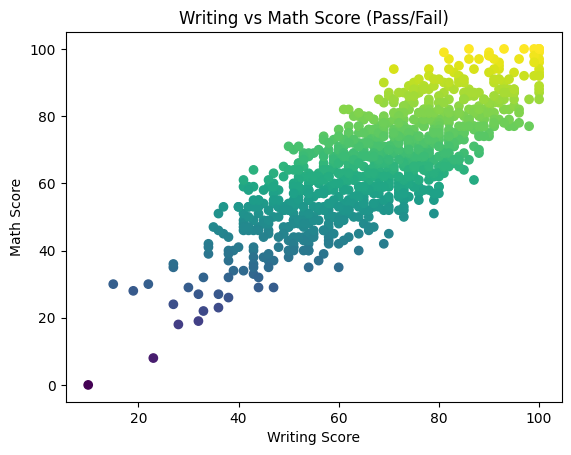

In [51]:
plt.figure()

plt.scatter(
    df['writing score'],
    df['math score'],
    c=df['math score']
)

plt.xlabel('Writing Score')
plt.ylabel('Math Score')
plt.title('Writing vs Math Score (Pass/Fail)')

plt.show()

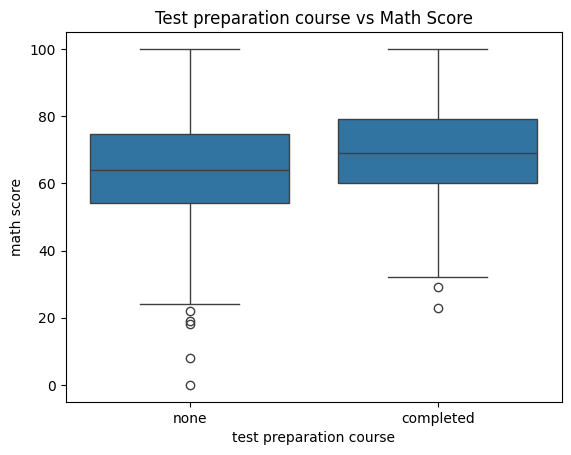

In [53]:
sns.boxplot(x='test preparation course', y='math score', data=df)
plt.title("Test preparation course vs Math Score")
plt.show()

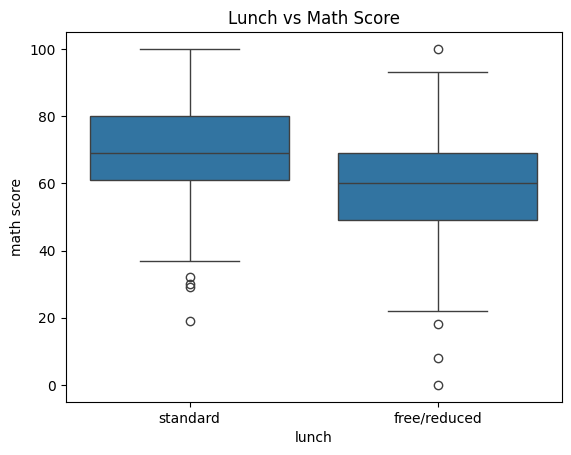

In [54]:
sns.boxplot(x='lunch', y='math score', data=df)
plt.title("Lunch vs Math Score")
plt.show()

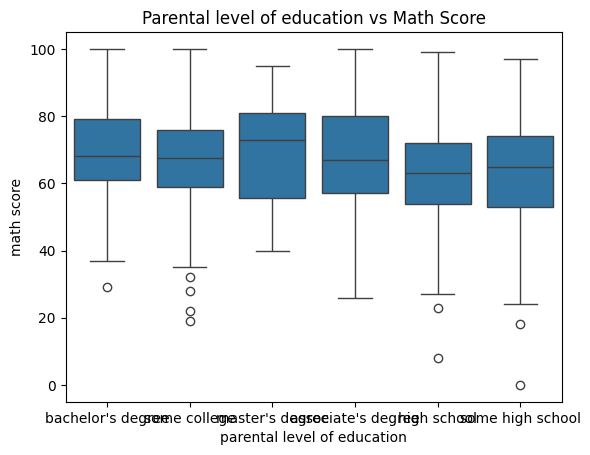

In [55]:
sns.boxplot(x='parental level of education', y='math score', data=df)
plt.title("Parental level of education vs Math Score")
plt.show()

In [63]:
df['math_level'] = df['math score'].apply(lambda x: 1 if x >= 60 else 0)

In [70]:
#Logistic Classification model
#Select features (X) and target (y)
X = df[['reading score', 'writing score']]
y = df['math_level']

In [71]:
# Scale
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [72]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

In [74]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [75]:
y_pred = model.predict(X_test_scaled)

In [76]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.825


In [77]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.70      0.74        70
           1       0.85      0.89      0.87       130

    accuracy                           0.82       200
   macro avg       0.81      0.80      0.80       200
weighted avg       0.82      0.82      0.82       200



In [79]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 49  21]
 [ 14 116]]


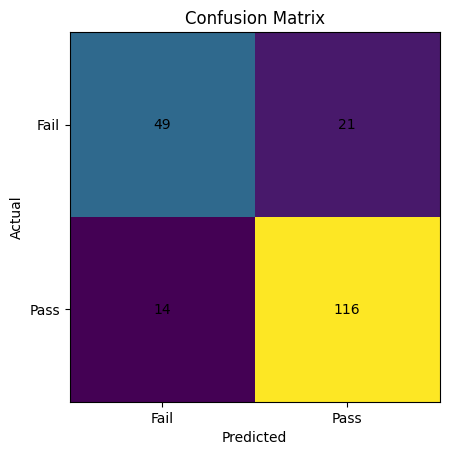

In [80]:
plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0,1], ['Fail','Pass'])
plt.yticks([0,1], ['Fail','Pass'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha='center', va='center')

plt.show()

In [87]:
#Test data
sample = [[100, 100]]  # reading, writing

sample_scaled = scaler.transform(sample)
prediction = model.predict(sample_scaled)

if prediction[0] == 1:
    print("Prediction: Pass")
else:
    print("Prediction: Fail")

Prediction: Pass


/home/jupyter-st125881/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/jupyter-st125881/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
